<font color=#009afa size=50>DAT-6002 - Fundamentals of Artificial Intelligence</font><br>
<font size=50>WRIT1 Part 2 - Neural Networks</font><br>
<font size=20 color=#00c382>MLP using SciKitLearn - Bank Data</font><br>

|**Assessment Code:** |WRIT1|
|---|---|
|**Author:**|Tom Rowan|
|**Course:**|DAT6002_S2_25|
|**Course Tutor:**|Imtiaz Hussain Khan, PhD|


**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**

https://archive.ics.uci.edu/dataset/222/bank+marketing

---

# Initialise Notebook

In [3]:
# Install Requirements Using Pip
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Import Python Libraries

In [4]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Plotly
import plotly.express as px
import plotly.graph_objects as go

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Pycountry 
import pycountry

# GeoPy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# IPython Display 
from IPython.display import HTML

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [5]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [6]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow'):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}')

### Check for Internet Access

In [7]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [8]:
internet_required = False

In [9]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Load the Dataset

In [10]:
if online:
    # Fetch the dataset from the Internet
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')
else:
    # Load the dataset from local file
    df = pd.read_csv('bank_full_scaled_latest.csv', delimiter=',')

In [11]:
df.sample(10)

,age,default,balance,housing,loan,day,y,job_admin.,job_blue-collar,job_entrepreneur,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
20670,0.233766,0.0,0.072803,0.0,0.0,0.366667,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
252,0.207792,0.0,0.072803,1.0,0.0,0.133333,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5348,0.194805,0.0,0.069580,1.0,0.0,0.733333,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
18317,0.246753,0.0,0.073366,0.0,0.0,1.000000,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
36682,0.090909,0.0,0.081101,1.0,0.0,0.366667,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
22593,0.259740,0.0,0.075672,0.0,0.0,0.700000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
44680,0.116883,0.0,0.077888,0.0,0.0,0.066667,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
12216,0.350649,0.0,0.104507,1.0,1.0,0.633333,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12707,0.272727,0.0,0.081946,1.0,0.0,0.200000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1122,0.298701,0.0,0.075146,1.0,0.0,0.200000,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Now it is necessary to split the input dataset into two parts - testing and training data

In [12]:
# Split data frame into 80/20
df_train = df.sample(frac = 0.8)
# Creating dataframe with rest of the 20% values
df_test = df.drop(df_train.index)

In [13]:
print_output("df_train shape", df_train.shape)
print_output("df_test shape", df_test.shape)

df_train shape: (36169, 45)
df_test shape: (9042, 45)


In [ ]:
# Split datasets into X (features) and y (labels)
df_X_train = df_train.drop(columns='y')
df_y_train = df_train['y']

df_X_test = df_test.drop(columns='y')
df_y_test = df_test['y']


X_np_train shape: (36169, 44)
y_np_train shape: (36169, 1)
X_np_test shape: (9042, 44)
y_np_test shape: (9042, 1)


In [26]:
df_X_train.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'month_apr', 'month_aug', 'month_dec', 'month_feb',
       'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'poutcome_failure',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype='str')

# Neural Network

"Construct a three-layer feedforward neural network consisting of N input neurons, 10 hidden neurons, and M output neuron(s)."

In a neural network, the forward pass consists of two main operations per layer:

    Linear Transformation: Z=X⋅W+b

    Activation Function: A=σ(Z)

For a binary classification task like this, the Sigmoid function is the standard choice for the output layer because it squashes any input into a value between 0 and 1, which we can interpret as a probability.  (citation)

## MLP Class 

In [102]:
class MLP_From_Scratch:

    # Constructor
    def __init__(self, X_train, y_train, X_test, y_test, **kwargs):

        # Convert to numpy arrays
        self.X_np_train = df_X_train.to_numpy()
        self.y_np_train = df_y_train.to_numpy().reshape(-1,1)

        self.X_np_test = df_X_test.to_numpy()
        self.y_np_test = df_y_test.to_numpy().reshape(-1,1)

        # Handle Additional Arguments
        _random_seed = kwargs.get('random_seed', 67)
        _debug = kwargs.get('debug', False)

        # Additional Model Parameters
        _act_func = kwargs.get('act_func', 'sigmoid')
        _no_hidden_neurons = kwargs.get('no_hidden_neurons', 10)    # Defaults to 10 hidden neurons, per assessment specification
        _no_output_neurons = kwargs.get('no_output_neurons', 1)
        _learning_rate = kwargs.get('learning_rate', 0.03)

        # Define layer sizes
        self.no_input_neurons  = self.X_np_train.shape[1]    # Set dynamically based on the input dataset
        self.no_hidden_neurons = _no_hidden_neurons          
        self.no_output_neurons = _no_output_neurons
        self.learning_rate = _learning_rate          

        # Initialize Weights with small random numbers
        # 
        #   input_neurons --> weights_0 --> hidden_neurons --> weights_1 --> output_neurons
        #                                   biases_1                         biases_2
        #
        np.random.seed(_random_seed)

        self.weights_0 = np.random.randn(self.no_input_neurons, self.no_hidden_neurons) 
        self.weights_1 = np.random.randn(self.no_hidden_neurons, self.no_output_neurons)

        self.biases_1 = np.zeros((1, self.no_hidden_neurons))
        self.biases_2 = np.zeros((1, self.no_output_neurons))


        if _debug:
            print_output("No Input Layer Neurons", self.no_input_neurons, colour='blue')
            print_output("No Input to Hidden Weights", self.weights_0.size)

            print_output("No Hidden Layer Neurons", self.no_hidden_neurons, colour='blue')
            print_output("No Hidden Layer Biases", self.biases_1.size, colour='blue')

            print_output("No Hidden to Output Weights", self.weights_1.size)

            print_output("No Output Layer Neurons", self.no_output_neurons, colour='blue')
            print_output("No Output Layer Biases", self.biases_2.size, colour='blue')


    # end Constructor

    # ***** Activation Functions 

    def _relu(self, x):
        return np.maximum(0, x)

    def _relu_derivative(self, x):
        return (x > 0).astype(float)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        return x * (1 - x)

    # Generic version to allow replacement
    def _act_func(self, x):
        return self._sigmoid(x)

    def _act_func_deriv(self, x):
        return self._sigmoid_derivative(x)
    
    # ***** MLP Process Functions 

    def _feed_forward(self, X):
        sum_synapse_0 = np.dot(X, self.weights_0) + self.biases_1
        hidden_layer = self._act_func(sum_synapse_0)
        
        sum_synapse_1 = np.dot(hidden_layer, self.weights_1) + self.biases_2
        output_layer = self._act_func(sum_synapse_1)
        
        # Return everything
        return X, hidden_layer, output_layer
    

    def _back_propagation(self, output_layer):
        error_output_layer = self.y_np_train - output_layer
        average_error = np.mean(abs(error_output_layer))
        
        derivative_output = self._act_func_deriv(output_layer)
        delta_output = error_output_layer * derivative_output

        return delta_output, average_error
    
    
    def _back_propagation_hidden(self, delta_output, hidden_layer):
    
        # Transpose the numpy array
        weights_1T = self.weights_1.T
        
        delta_output_weight = delta_output.dot(weights_1T)
        delta_hidden_layer = delta_output_weight * self._act_func_deriv(hidden_layer)
        
        hidden_layerT = hidden_layer.T
        input_x_delta1 = hidden_layerT.dot(delta_output)

        return delta_hidden_layer, input_x_delta1
    

    def _weight_bias_update(self, input_layer, input_x_delta1, delta_hidden_layer, delta_output):
        #global weights_0, weights_1, biases_1, biases_2, learning_rate

        m = input_layer.shape[0]                                           # Batch size to normalise the gradient
        
        self.weights_1 = self.weights_1 + (input_x_delta1 / m * self.learning_rate)       # Divide by m to compute the average gradient
        
        input_layerT = input_layer.T
        input_x_delta0 = input_layerT.dot(delta_hidden_layer)
        self.weights_0 = self.weights_0 + (input_x_delta0 / m * self.learning_rate)                                                            

        self.biases_1 = self.biases_1 + np.sum(delta_hidden_layer, axis=0, keepdims=True) / m * self.learning_rate
        self.biases_2 = self.biases_2 + np.sum(delta_output, axis=0, keepdims=True) / m * self.learning_rate 

    # ***** Public Functions 

    def train_network (self, epochs):
        
        learning_rate = self.learning_rate
        self.error = []

        for epoch in range(epochs):
            input_layer, hidden_layer, output_layer = self._feed_forward(self.X_np_train)       # Calling feedForward method

            delta_output, average_error = self._back_propagation(output_layer)                                             # Calling backPropagation method

            if epoch % 100 == 0:
                print('Epoch: ' + str(epoch + 1) + ' Error: ' + str(average_error))
                self.error.append(average_error)

            delta_hidden_layer, input_x_delta1 = self._back_propagation_hidden(delta_output, hidden_layer)                # Calling backPropagationHidden method

            self._weight_bias_update(input_layer, input_x_delta1, delta_hidden_layer, delta_output)                       # Calling weightBiasUpdate method

    def plot_error (self):
        plt.xlabel('Number of Epochs')
        plt.ylabel('Error')
        plt.title('Plot showing results from Neural Network')
        plt.plot(self.error)
        plt.show()
        

This is a binary classification problem, which implies 1 output neuron

In [ ]:
mlp = MLP_From_Scratch(df_X_train, df_y_train, df_X_test, df_y_test, debug=True)
mlp.train_network(epochs=2000)
mlp.plot_error()


No Input Layer Neurons: 44
No Input to Hidden Weights: 440
No Hidden Layer Neurons: 10
No Hidden Layer Biases: 10
No Hidden to Output Weights: 10
No Output Layer Neurons: 1
No Output Layer Biases: 1
Epoch: 1 Error: 0.7869107478355545
Epoch: 101 Error: 0.6471262344862319
Epoch: 201 Error: 0.43843555895342584
Epoch: 301 Error: 0.3291054772907852
Epoch: 401 Error: 0.2795437335831728
Epoch: 501 Error: 0.25287209594565146
Epoch: 601 Error: 0.23642736614645946
Epoch: 701 Error: 0.2253261630147298
Epoch: 801 Error: 0.21735398574451636
Epoch: 901 Error: 0.21137171553951925
Epoch: 1001 Error: 0.20673523644955355
Epoch: 1101 Error: 0.20305299335160606
Epoch: 1201 Error: 0.2000730629458289
Epoch: 1301 Error: 0.19762580655032858
Epoch: 1401 Error: 0.19559265144019108
Epoch: 1501 Error: 0.1938881002460327
Epoch: 1601 Error: 0.19244886025596658
Epoch: 1701 Error: 0.1912270067951106
Epoch: 1801 Error: 0.19018553412036437
Epoch: 1901 Error: 0.18929537326196774


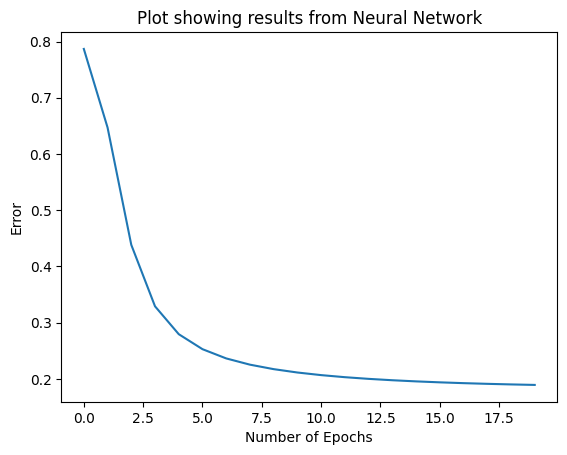

In [104]:
mlp.plot_error()

In [ ]:
sys.exit('Stopping notebook run here.')   

To know how "wrong" the network is, we use Binary Cross-Entropy Loss (also called Log Loss). This is much more effective for classification than Mean Squared Error.
Loss=−m1​∑[y⋅log(y^​)+(1−y)⋅log(1−y^​)]

In [59]:
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    # Adding a tiny epsilon (1e-15) prevents log(0) which would result in NaN
    loss = -1/m * np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))
    return loss

In [60]:
def back_propagation(X, y, Z1, A1, Z2, A2, W1, W2):
    m = X.shape[0]
    
    # 1. Output Layer Gradients
    dZ2 = A2 - y  # Error signal at the end
    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
    
    # 2. Hidden Layer Gradients
    # We pass the error back through W2 and then through the Sigmoid derivative
    dZ1 = np.dot(dZ2, W2.T) * act_func_deriv(A1)
    dW1 = (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
    
    return dW1, db1, dW2, db2

In [32]:
def train_network(X, y, epochs=1000, learning_rate=0.1):
    # 1. Initialize Weights with the Seed (Reproduction)
    np.random.seed(42)
    input_size = X.shape[1]
    hidden_size = 16
    output_size = 1
    
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    
    loss_history = []

    for i in range(epochs):
        # 2. Forward Propagation
        Z1, A1, Z2, A2 = forward_propagation(X, W1, b1, W2, b2)
        
        # 3. Compute and store Loss
        current_loss = compute_loss(y, A2)
        loss_history.append(current_loss)
        
        # 4. Backpropagation (Calculate Gradients)
        dW1, db1, dW2, db2 = back_propagation(X, y, Z1, A1, Z2, A2, W1, W2)
        
        # 5. Gradient Descent (Update Weights)
        # New Weight = Old Weight - (Learning Rate * Gradient)
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        
        # 6. Print progress every 100 epochs
        if i % 100 == 0:
            print(f"Epoch {i}: Loss {current_loss:.4f}")
            
    return W1, b1, W2, b2, loss_history

In [33]:
# Train the MLP
W1_final, b1_final, W2_final, b2_final, history = train_network(X_np_train, y_np_train, epochs=2000, learning_rate=0.5)

# Final Accuracy Check
_, _, _, final_preds = forward_propagation(X_np_train, W1_final, b1_final, W2_final, b2_final)
final_accuracy = np.mean((final_preds > 0.5) == y_np_train) * 100
print(f"\nFinal Accuracy: {final_accuracy:.2f}%")

Epoch 0: Loss 0.6932
Epoch 100: Loss 0.3522
Epoch 200: Loss 0.3466
Epoch 300: Loss 0.3404
Epoch 400: Loss 0.3339
Epoch 500: Loss 0.3277
Epoch 600: Loss 0.3223
Epoch 700: Loss 0.3179
Epoch 800: Loss 0.3142
Epoch 900: Loss 0.3112
Epoch 1000: Loss 0.3088
Epoch 1100: Loss 0.3068
Epoch 1200: Loss 0.3052
Epoch 1300: Loss 0.3039
Epoch 1400: Loss 0.3028
Epoch 1500: Loss 0.3020
Epoch 1600: Loss 0.3013
Epoch 1700: Loss 0.3008
Epoch 1800: Loss 0.3004
Epoch 1900: Loss 0.3000

Final Accuracy: 89.47%


In [ ]:
# Use the final weights to predict on the TEST set
_, _, _, test_probs = forward_propagation(X_np_test, W1_final, b1_final, W2_final, b2_final)

# Convert probabilities to 0 or 1
test_preds = (test_probs > 0.5).astype(int)

# Calculate Accuracy
test_accuracy = np.mean(test_preds == y_np_test) * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 88.58%


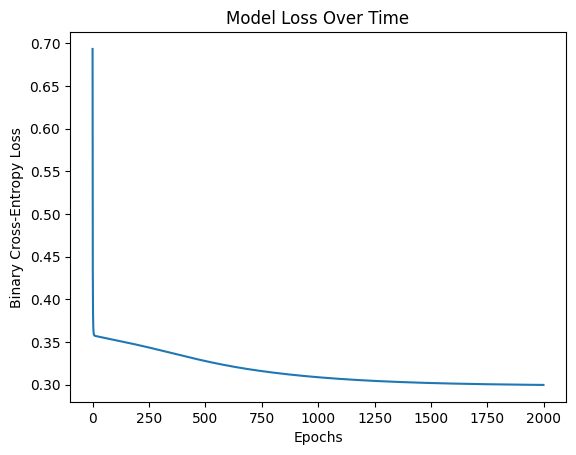

In [35]:
import matplotlib.pyplot as plt

plt.plot(history)
plt.title('Model Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')
plt.show()

SystemExit: Stopping notebook run here.

---